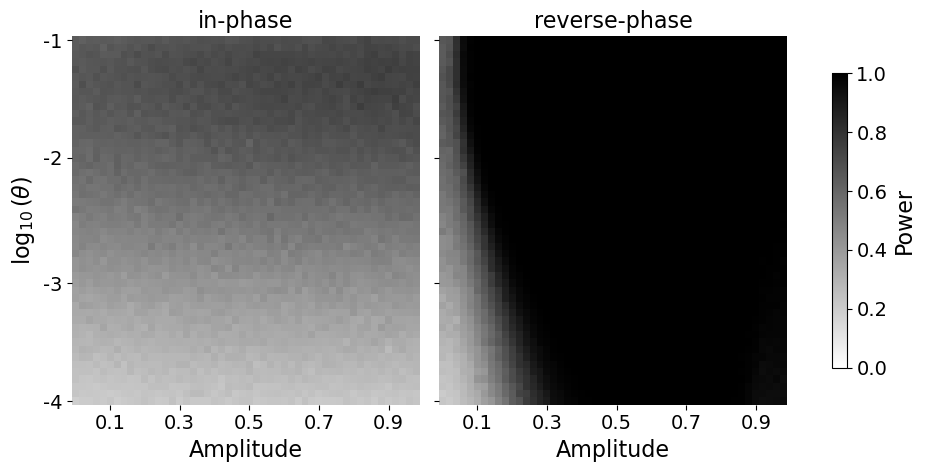

In [26]:
# Cell 0: Power Heatmap (sync vs async)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

plt.rcParams.update({'font.size': 16, 'axes.titlesize': 18, 'axes.labelsize': 16,
                     'xtick.labelsize': 14, 'ytick.labelsize': 14, 'legend.fontsize': 14})

df = pd.read_csv("outputs/crlb.csv", index_col=None)
df = df.rename(columns={'delta': 'amplitude'})
df['phase2'] = df.phase2.replace({np.pi: 'reverse-phase', 0: 'in-phase'})
df['crlb'] = df.crlb / np.sqrt(20)
df['log_crlb'] = np.log10(df.crlb)
df['log_theta'] = np.log10(df.theta)

z_alpha = 1.645
df['power'] = 1 - norm.cdf(z_alpha - df['theta'] / df['crlb'])
df_agg = df.groupby(['theta', 'amplitude', 'phase2'])['power'].mean().reset_index()

def draw_heatmap(data, **kwargs):
    pivot = data.pivot(index='theta', columns='amplitude', values='power')
    thetas = pivot.index.values
    amplitudes = pivot.columns.values
    ax = plt.gca()
    sns.heatmap(pivot, ax=ax, cmap='gray_r', vmin=0, vmax=1, cbar=False,
                xticklabels=False, yticklabels=False)
    ax.invert_yaxis()
    x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
    x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_desired)
    y_desired_theta = [0.1, 0.01, 0.001, 0.0001]
    y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired_theta]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(['-1', '-2', '-3', '-4'])

g = sns.FacetGrid(df_agg, col='phase2', height=5, aspect=1)
g.map_dataframe(draw_heatmap)
g.set_axis_labels('Amplitude', r'$\log_{10}(\theta)$')
g.set_titles(col_template='{col_name}')
sm = plt.cm.ScalarMappable(cmap='gray_r', norm=plt.Normalize(0, 1))
sm.set_array([])
g.figure.colorbar(sm, ax=g.axes, location='right', shrink=0.8, label='Power')
plt.savefig("pix/power.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/power.pdf", bbox_inches='tight')
plt.show()

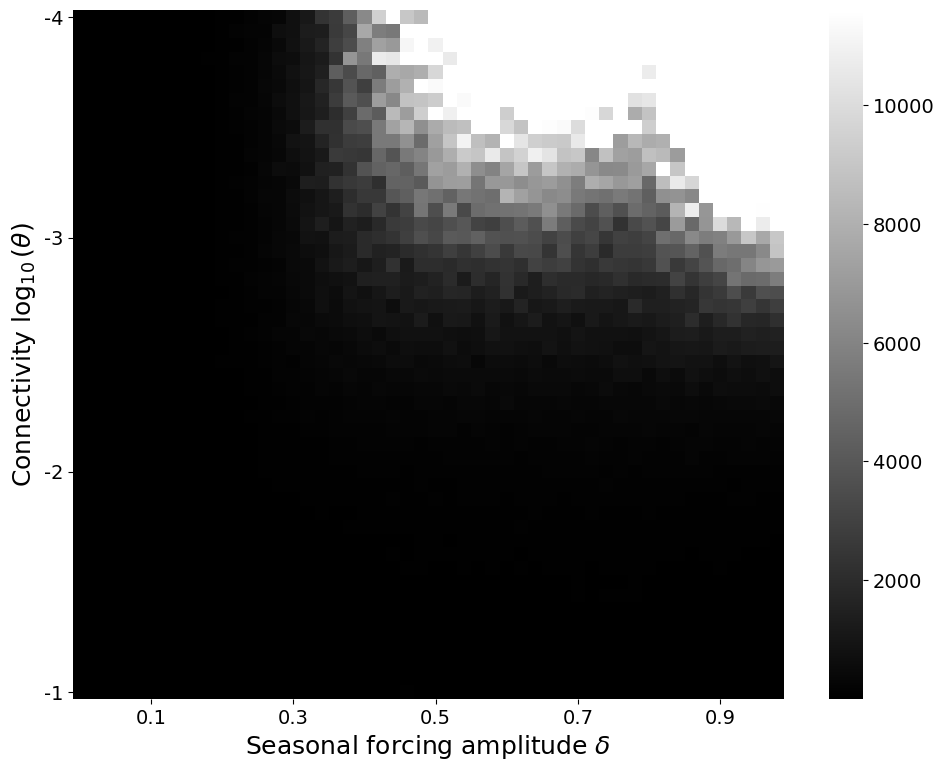

In [27]:
# Cell 1: CRLB Ratio Heatmap (sync / unsync)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

def median_ratio(pp):
    sync = pp.query("phase2 == 0").crlb.values
    unsync = pp.query("phase2 > 0").crlb.values
    ret =  np.median(sync) / np.median(unsync)
    return ret

    
df = pd.read_csv("outputs/crlb.csv")
df = df.rename(columns={'delta': 'amplitude'})
groups = list(df.groupby(['amplitude', 'theta']))
results = Parallel(n_jobs=-1)(delayed(median_ratio)(group) for name, group in groups)
index = pd.MultiIndex.from_tuples([name for name, group in groups], names=['amplitude', 'theta'])
agg = pd.Series(results, index=index)

heat = agg.unstack(level='amplitude')
heat.index = np.log10(heat.index)
vmax = np.percentile(heat.values.flatten(), 90)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(heat, cmap='grey', xticklabels=False, yticklabels=False, vmin=1, vmax=vmax)
amplitudes = heat.columns.values
thetas = heat.index.values
x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
ax.set_xticks(x_positions)
ax.set_xticklabels(x_desired)
y_desired = [-1, -2, -3, -4]
y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired]
ax.set_yticks(y_positions)
ax.set_yticklabels(y_desired)
plt.ylabel(r'Connectivity $\log_{10}(\theta)$', fontsize=18)
plt.xlabel(r'Seasonal forcing amplitude $\delta$', fontsize=18)
plt.tight_layout()
plt.savefig("pix/crlb_ratio.png", dpi=150)
plt.savefig("pix/crlb_ratio.pdf")
plt.show()

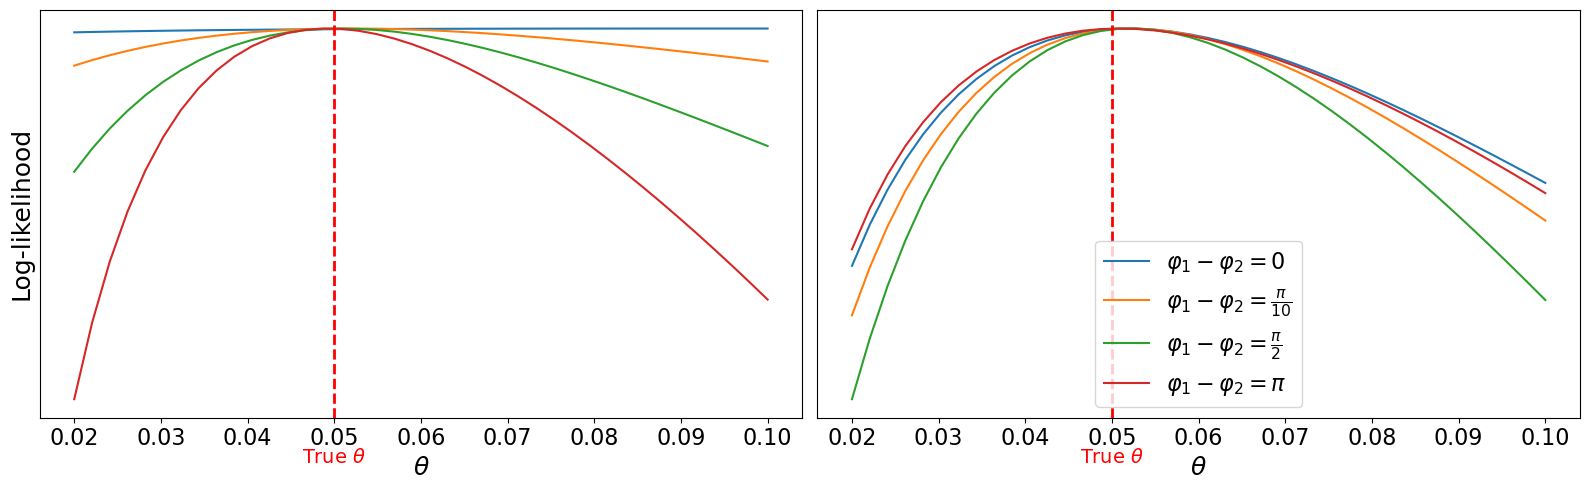

In [5]:
# Cell 2: Profile Likelihood Surface — two panels
# Left: similar ICs. Right: different ICs.
# Both sweep over the same four phase differences.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src import flu
from src.packer import Packer
from src.objective import Objective

N_POP = 1e7
disease = flu.Mortality
regions = ["A", "B"]
n_season = 10
seasons = list(range(n_season))
thetas = np.linspace(0.02, 0.1, 40)
populations = {(s, r): N_POP for s in seasons for r in regions}
packer = Packer(disease=disease, seasons=seasons, regions=regions, populations=populations)
theta = 0.05

np.random.seed(0)

# Similar ICs: drawn from narrow ranges independently
S_sim = np.column_stack([np.random.uniform(*disease.slim_similar, size=n_season),
                         np.random.uniform(*disease.slim_similar, size=n_season)])
I_sim = np.column_stack([np.random.uniform(*disease.ilim_similar, size=n_season),
                         np.random.uniform(*disease.ilim_similar, size=n_season)])

# Different ICs: drawn from wide ranges independently
S_dif = np.column_stack([np.random.uniform(*disease.slim_different, size=n_season),
                         np.random.uniform(*disease.slim_different, size=n_season)])
I_dif = np.column_stack([np.random.uniform(*disease.ilim_different, size=n_season),
                         np.random.uniform(*disease.ilim_different, size=n_season)])

phases = [0, np.pi/10, np.pi/2, np.pi]
labels = [r"$\varphi_1-\varphi_2=0$", r"$\varphi_1-\varphi_2=\frac{\pi}{10}$",
          r"$\varphi_1-\varphi_2 = \frac{\pi}{2}$", r"$\varphi_1-\varphi_2= \pi$"]

panels = [
    (S_sim, I_sim),
    (S_dif, I_dif),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for ax, (S_init, I_init) in zip([ax1, ax2], panels):
    true = dict(S_init=S_init, I_init=I_init, theta=theta)

    for phase2, label in zip(phases, labels):
        phase = np.array([0.0, phase2])
        obs = packer.sim(true, phase, disease)
        mu = obs['mu']
        np.random.seed(42)
        obs['incidence'] = mu * disease.rho + np.random.randn(len(mu)) * np.sqrt(disease.rho * (1 - disease.rho) * mu)
        obj = Objective(obs=obs, phase=phase, disease=disease, populations=populations)
        lls = np.array([-obj(packer.pack(dict(true, theta=th))) for th in thetas])
        ax.plot(thetas, lls - lls.max(), label=label)

    ax.axvline(x=theta, color='red', linestyle='--', linewidth=2)
    ax.annotate(rf'True $\theta$', xy=(theta, 0), xycoords=('data', 'axes fraction'),
                xytext=(0, -22), textcoords='offset points',
                ha='center', va='top', fontsize=14, color='red')
    ax.set_xlabel(r"$\theta$", fontsize=18)
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=16)

ax1.set_ylabel("Log-likelihood", fontsize=18)
ax2.legend(fontsize=16)

plt.tight_layout()
plt.savefig("pix/likelihood_surface.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/likelihood_surface.pdf", bbox_inches='tight')
plt.show()

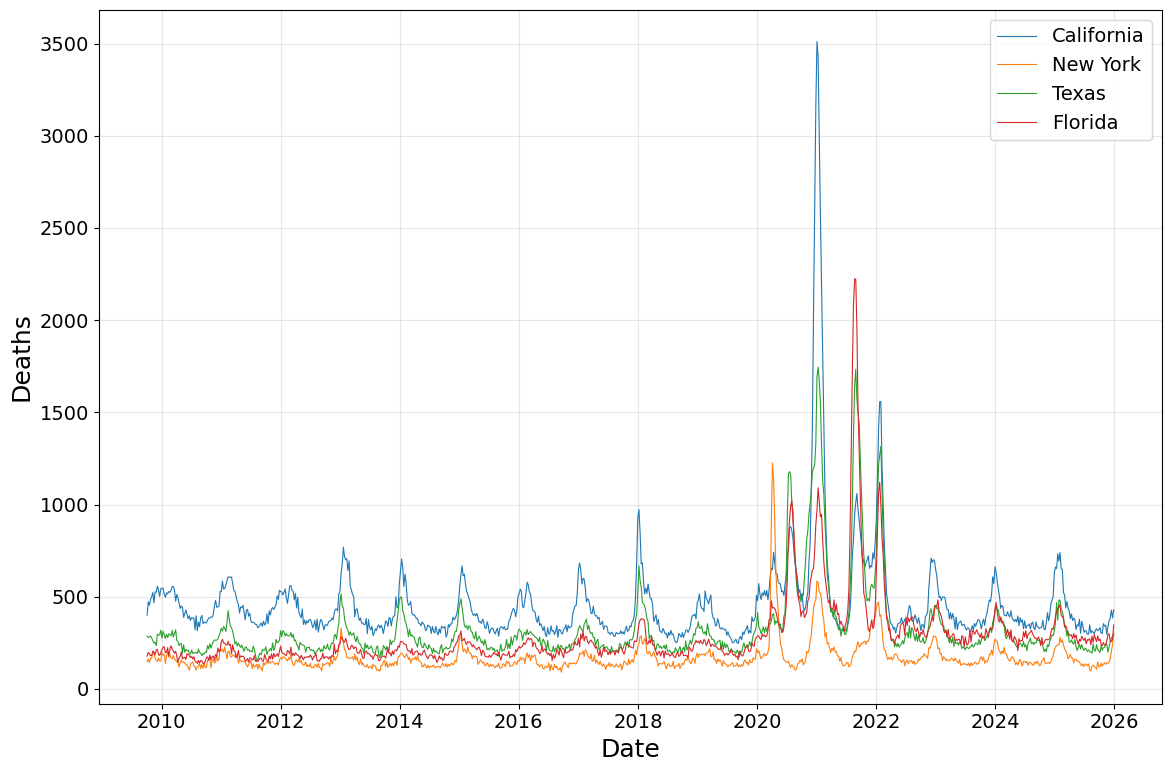

In [29]:
# Cell 3: Raw P&I Death Counts for Representative States
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/pni_mortality/deaths.csv", parse_dates=["date"])
states = ["California", "New York", "Texas", "Florida"]
df = df[df["state"].isin(states)].sort_values("date")

fig, ax = plt.subplots(1, 1, figsize=(12, 8), sharex=True)
for state in states:
    dd = df[df["state"] == state]
    ax.plot(dd["date"], dd["deaths"], linewidth=0.8, label=state)
ax.set_ylabel("Deaths", fontsize=18)
ax.set_xlabel("Date", fontsize=18)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=14)
plt.tight_layout()
plt.savefig("pix/raw_deaths.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/raw_deaths.pdf", bbox_inches='tight')
plt.show()

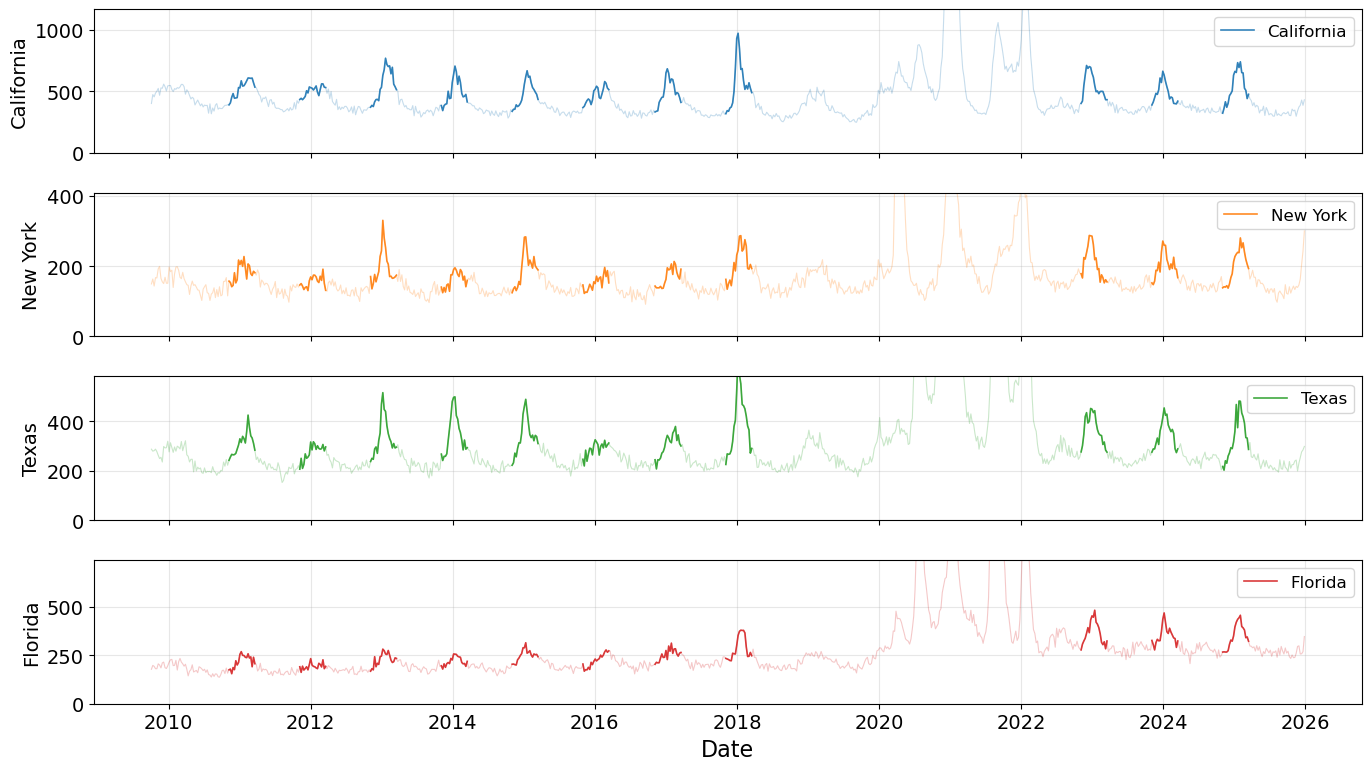

In [30]:
# P&I Deaths with flu seasons highlighted
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.flu import Mortality as flu

df = pd.read_csv("data/pni_mortality/deaths.csv", parse_dates=["date"])
states = ["California", "New York", "Texas", "Florida"]
colors = {"California": "C0", "New York": "C1", "Texas": "C2", "Florida": "C3"}
seasons = list(range(2011, 2019)) + [2023, 2024, 2025]
n_weeks = flu.n_weeks

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)

for ax, state in zip(axes, states):
    dd = df[df["state"] == state].sort_values("date")
    c = colors[state]

    # Full time series: light, transparent
    ax.plot(dd["date"], dd["deaths"], color=c, linewidth=0.8, alpha=0.25)

    # Flu seasons: dark, opaque
    for s_idx, season in enumerate(seasons):
        start = pd.Timestamp(year=season - 1, month=11, day=1)
        end = start + pd.Timedelta(weeks=n_weeks)
        mask = (dd["date"] >= start) & (dd["date"] < end)
        ss = dd[mask]
        if not ss.empty:
            ax.plot(ss["date"], ss["deaths"], color=c, linewidth=1.2, alpha=0.9,
                    label=state if s_idx == 0 else None)

    ax.set_ylim(0, dd["deaths"].max() / 3)
    ax.set_ylabel(state, fontsize=14)
    ax.legend(loc='upper right', fontsize=12)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date", fontsize=16)
plt.tight_layout()
plt.savefig("pix/seasons_highlighted.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/seasons_highlighted.pdf", bbox_inches='tight')
plt.show()

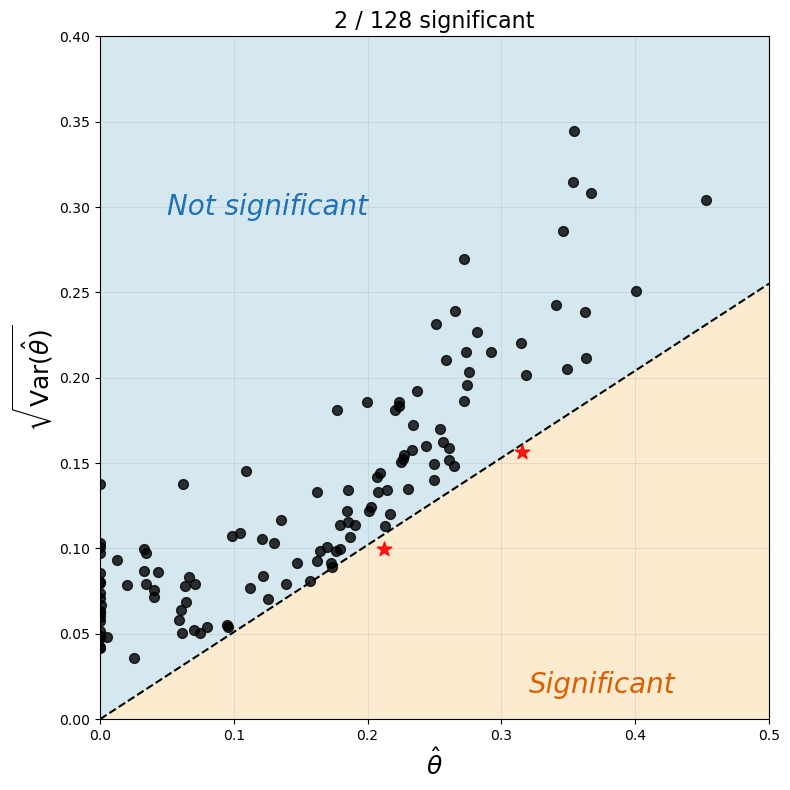

In [8]:
# Theta estimate vs CRLB std with significance regions
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob

states = ['CA', 'TX', 'FL', 'NY', 'PA', 'IL', 'OH', 'GA', 'NC', 'MI',
          'NJ', 'VA', 'WA', 'AZ', 'MA', 'TN', 'IN', 'MD', 'MO', 'WI']

res = pd.concat([pd.read_csv(f) for f in glob("outputs/states/*.csv")], ignore_index=True)
res = res.query("state1 in @states and state2 in @states")
pairs = res.groupby(['state1', 'state2']).first().reset_index()
pairs['significant'] = pairs['theta'] > 1.96 * pairs['crlb4std']

fig, ax = plt.subplots(figsize=(8, 8))

theta_max = 0.5
crlb_max = 0.4
t = np.linspace(0, theta_max, 100)
threshold = t / 1.96

# Shaded regions
ax.fill_between(t, threshold, crlb_max, color='#D5E8F0', zorder=0)
ax.fill_between(t, 0, threshold, color='#FDEBD0', zorder=0)
ax.plot(t, threshold, 'k--', linewidth=1.5, zorder=2)

# Non-significant points: black circles
nonsig = pairs[~pairs['significant']]
ax.scatter(nonsig['theta'], nonsig['crlb4std'], alpha=0.8, s=50, color='black',
           marker='o', zorder=3)

# Significant points: red stars
sig = pairs[pairs['significant']]
ax.scatter(sig['theta'], sig['crlb4std'], alpha=0.9, s=120, color='red',
           marker='*', zorder=4)

# Region labels
ax.text(0.25 * theta_max, 0.75 * crlb_max, 'Not significant',
        fontsize=20, color='#2171B5', ha='center', va='center', fontstyle='italic')
ax.text(0.75 * theta_max, 0.05 * crlb_max, 'Significant',
        fontsize=20, color='#D95F02', ha='center', va='center', fontstyle='italic')

ax.set_xlim(0, theta_max)
ax.set_ylim(0, crlb_max)
ax.set_xlabel(r'$\hat{\theta}$', fontsize=18)
ax.set_ylabel(r'$\sqrt{\text{Var}(\hat{\theta})}$', fontsize=18)
ax.grid(True, alpha=0.3)

n_sig = sig.shape[0]
n_total = len(pairs)
ax.set_title(f'{n_sig} / {n_total} significant', fontsize=16)

plt.tight_layout()
plt.savefig("pix/theta_vs_crlb.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/theta_vs_crlb.pdf", bbox_inches='tight')
plt.show()